## Import Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

## Load Dataset

In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

## Explore Dataset

In [3]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train_df.shape

(1460, 81)

In [5]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
train_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [8]:
train_df.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

In [9]:
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## EDA (Exploratory Data Analysis)

In [10]:
train_df["SalePrice"].head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

In [11]:
train_df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [12]:
numerical_cols = train_df.select_dtypes(include=["int64", "float64"]).columns

categorical_cols = train_df.select_dtypes(include=["object"]).columns

print("Numerical Columns:", len(numerical_cols))
print("Categorical Columns:", len(categorical_cols))

Numerical Columns: 38
Categorical Columns: 43


C:\Users\DELL\AppData\Local\Temp\ipykernel_13936\1697182563.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df.select_dtypes(include=["object"]).columns


In [13]:
missing = train_df.isnull().sum()

missing = missing[missing > 0]

missing = (missing / len(train_df)) * 100

missing.sort_values(ascending=False)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

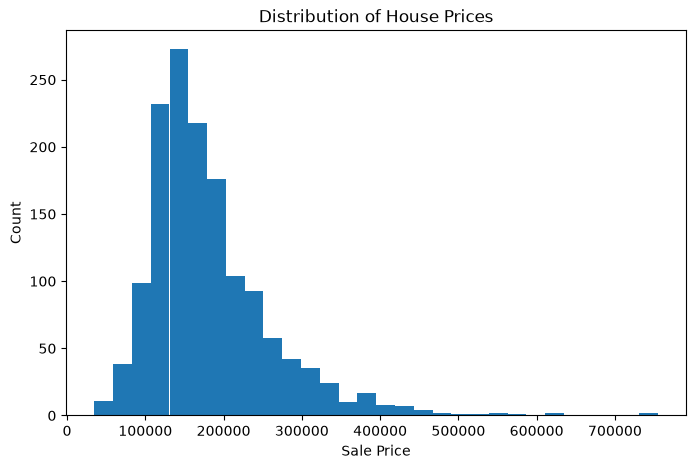

In [14]:
plt.figure(figsize=(8,5))
plt.hist(train_df["SalePrice"], bins=30)
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.title("Distribution of House Prices")
plt.show()

In [15]:
correlation = train_df.corr(numeric_only=True)

correlation["SalePrice"].sort_values(ascending=False).head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

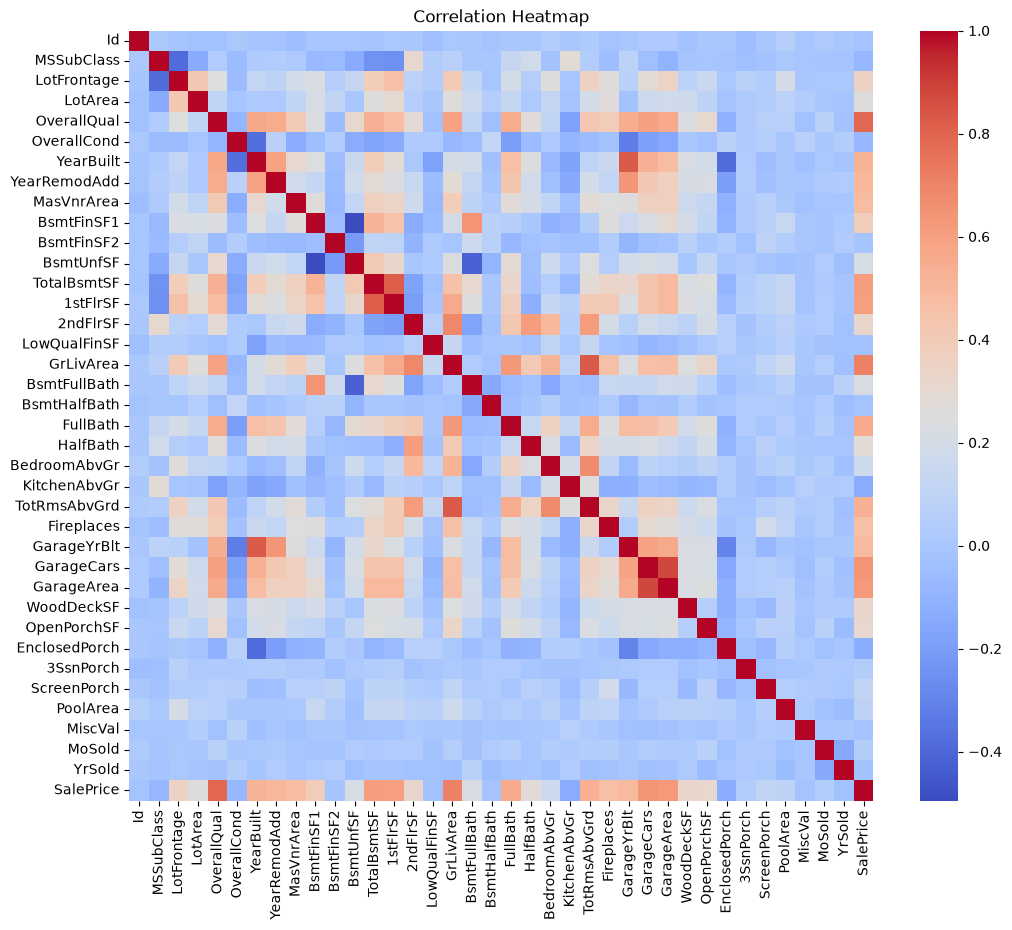

In [16]:
plt.figure(figsize=(12,10))
sns.heatmap(train_df.corr(numeric_only=True),cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

## Data Cleaning & Preprocessing

In [17]:
train_df.duplicated().sum()

# train_df = train_df.drop_duplicates() ->  Drop Duplicates

np.int64(0)

In [18]:
missing = train_df.isnull().sum()

missing = missing[missing > 0]

missing = pd.DataFrame({"Missing Values": missing, "Percentage": (missing / len(train_df)) * 100})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [19]:
missing[missing["Percentage"] > 50]

,Missing Values,Percentage
Alley,1369,93.767123
MasVnrType,872,59.726027
PoolQC,1453,99.520548
Fence,1179,80.753425
MiscFeature,1406,96.301370


In [20]:
num_cols = train_df.select_dtypes(include=["int64", "float64"]).columns

In [21]:
train_df[num_cols] = train_df[num_cols].fillna(train_df[num_cols].median())

In [22]:
cat_cols = train_df.select_dtypes(include=["object"]).columns

C:\Users\DELL\AppData\Local\Temp\ipykernel_13936\3636379355.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include=["object"]).columns


In [23]:
train_df[cat_cols] = train_df[cat_cols].fillna(train_df[cat_cols].mode().iloc[0])

In [24]:
train_df.isnull().sum().sum()

np.int64(0)

In [25]:
train_df = pd.get_dummies(train_df, drop_first=True)

In [26]:
x = train_df.drop("SalePrice", axis=1)
y = train_df["SalePrice"]

In [27]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
print(x.shape)
print(y.shape)
print(x_train.shape)
print(x_test.shape)
print(train_df.isnull().sum().sum())

(1460, 245)
(1460,)
(1168, 245)
(292, 245)
0


## Model Training & Comparison

### Linear Regression

In [29]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](245,)","[ 0.15, -97.91, -164.35,..., 5272.37, 6190.67,22550.57]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](245,)","['Id','MSSubClass','LotFrontage',...,'SaleCondition_Family', 'SaleCondition_Normal','SaleCondition_Partial']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9.486e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,245
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(234)


In [30]:
y_pred_linear = linear_model.predict(x_test)

In [31]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

print("MAE :", mean_absolute_error(y_test, y_pred_linear))
print("MSE :", mean_squared_error(y_test, y_pred_linear))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_linear)))
print("R2 Score:", r2_score(y_test, y_pred_linear))

MAE : 20383.824122216447
MSE : 1019680445.3134255
RMSE: 31932.435630772445
R2 Score: 0.8670616584262112


### Ridge Regression

In [32]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(x_train, y_train)

y_pred_ridge = ridge_model.predict(x_test)

In [33]:
print("MAE :", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2 :", r2_score(y_test, y_pred_ridge))

MAE : 19861.276523290144
RMSE: 30521.381156818727
R2 : 0.8785508357067084


### Lasso Regression

In [34]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1.0)

lasso_model.fit(x_train, y_train)

y_pred_lasso = lasso_model.predict(x_test)

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.207534e+11, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


### Decision Tree

In [35]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(x_train, y_train)

y_pred_dt = dt_model.predict(x_test)

### Random Forest

In [36]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100,random_state=42)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

### Compare Models

In [37]:
results = {"Model": ["Linear Regression","Ridge Regression","Lasso Regression","Decision Tree","Random Forest"],
        "R2 Score": [r2_score(y_test, y_pred_linear),r2_score(y_test, y_pred_ridge),r2_score(y_test, y_pred_lasso),r2_score(y_test, y_pred_dt),r2_score(y_test, y_pred_rf)]}

comparison = pd.DataFrame(results)

comparison.sort_values(by="R2 Score",ascending=False)

,Model,R2 Score
4,Random Forest,0.895201
1,Ridge Regression,0.878551
0,Linear Regression,0.867062
3,Decision Tree,0.795455
2,Lasso Regression,0.677176


## Hyperparameter Tuning (Random Forest)

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

In [39]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [40]:
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),param_grid=param_grid,cv=5,scoring="r2",n_jobs=-1)

In [41]:
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"v

In [42]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [43]:
best_rf = grid_search.best_estimator_

In [44]:
y_pred_best = best_rf.predict(x_test)

In [45]:
new_r2 = r2_score(y_test, y_pred_best)

print("R² Score After Tuning:", new_r2)

R² Score After Tuning: 0.8872696893401446


In [46]:
old_r2 = r2_score(y_test, y_pred_rf)

print("Before Tuning :", old_r2)
print("After Tuning  :", new_r2)

Before Tuning : 0.8952010298882774
After Tuning  : 0.8872696893401446


### Observation

Hyperparameter Tuning was performed using GridSearchCV.

The tuned model achieved an R² score of 0.8873, which was slightly lower than the baseline Random Forest model (0.8952).

Therefore, the original Random Forest model was selected as the final model because it provided better performance on the test dataset.

## Feature Importance

In [47]:
importance = pd.DataFrame({"Feature": x.columns,"Importance": rf_model.feature_importances_})

importance = importance.sort_values(by="Importance",ascending=False)

importance.head(10)

,Feature,Importance
4,OverallQual,0.557449
16,GrLivArea,0.120819
12,TotalBsmtSF,0.034973
14,2ndFlrSF,0.034354
9,BsmtFinSF1,0.029543
13,1stFlrSF,0.025664
3,LotArea,0.016596
27,GarageArea,0.016203
26,GarageCars,0.012389
6,YearBuilt,0.011702


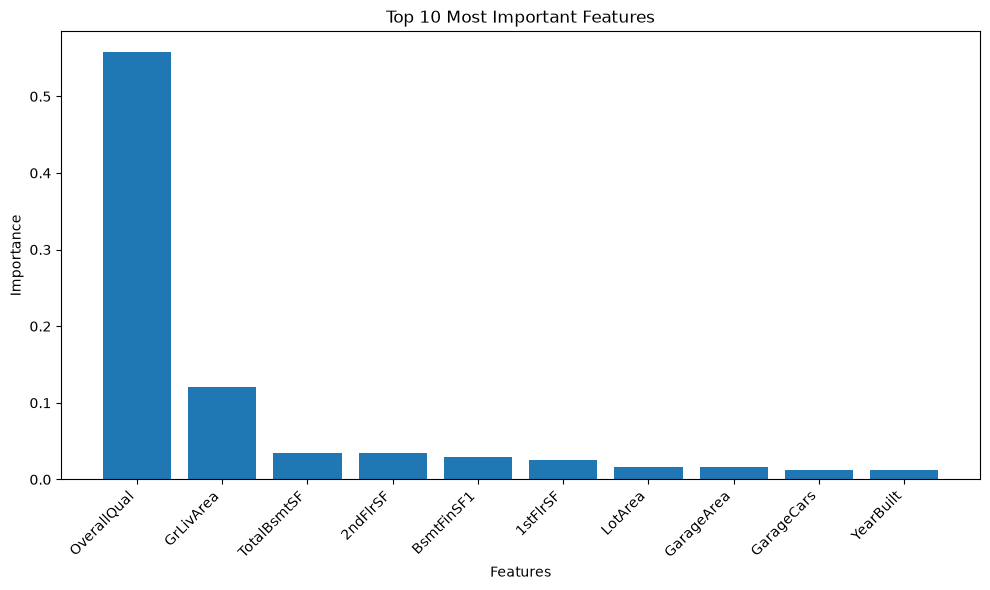

In [48]:
import matplotlib.pyplot as plt

top_features = importance.head(10)

plt.figure(figsize=(10,6))

plt.bar(top_features["Feature"],top_features["Importance"])

plt.xticks(rotation=45, ha="right")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Top 10 Most Important Features")

plt.tight_layout()
plt.show()

### Interpretation

The feature importance analysis shows which variables contributed the most to predicting house prices.

The top-ranked features have the greatest influence on the model's predictions, while features with very low importance have minimal impact.

In [49]:
predictions = rf_model.predict(x_test)

results = pd.DataFrame({"Actual Price": y_test.values,"Predicted Price": predictions})

results.head(10)

,Actual Price,Predicted Price
0,154500,141543.75
1,325000,320320.99
2,115000,117811.50
3,159000,153785.20
4,315500,317890.42
5,75500,86079.00
6,311500,210514.69
7,146000,151453.00
8,84500,85356.66
9,135500,129605.87


# Conclusion

This project focused on predicting house prices using multiple Machine Learning regression models.

### Workflow
- Imported and explored the dataset
- Performed data cleaning and preprocessing
- Handled missing values
- Encoded categorical variables
- Split the dataset into training and testing sets
- Trained multiple regression models
- Compared model performance
- Applied Hyperparameter Tuning
- Analyzed Feature Importance

### Model Performance

| Model | R² Score |
|-------|----------:|
| Random Forest | 0.8952 |
| Ridge Regression | 0.8786 |
| Linear Regression | 0.8671 |
| Decision Tree | 0.7955 |
| Lasso Regression | 0.6772 |

### Best Model

Random Forest Regressor achieved the highest R² score (0.8952), making it the best-performing model for this dataset.

Although Hyperparameter Tuning was performed using GridSearchCV, the tuned model (0.8873) did not outperform the original Random Forest model. Therefore, the original Random Forest model was selected as the final model.

--- 
## Note

This notebook was created for Machine Learning practice to understand the complete end-to-end regression workflow, including data preprocessing, model training, evaluation, and model comparison.